In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv("/content/drive/MyDrive/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [45]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


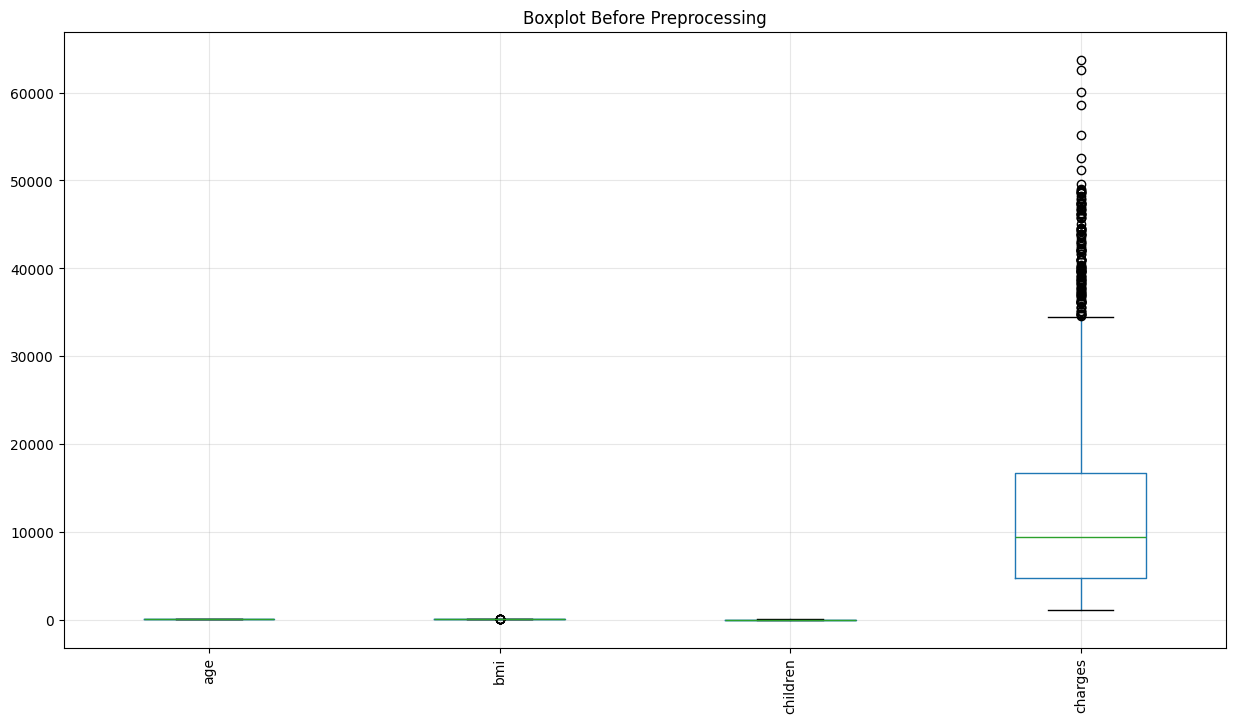

In [50]:
plt.figure(figsize=(15,8))

df.boxplot(rot=90)

plt.title("Boxplot Before Preprocessing")

plt.grid(alpha=0.3)
plt.show()

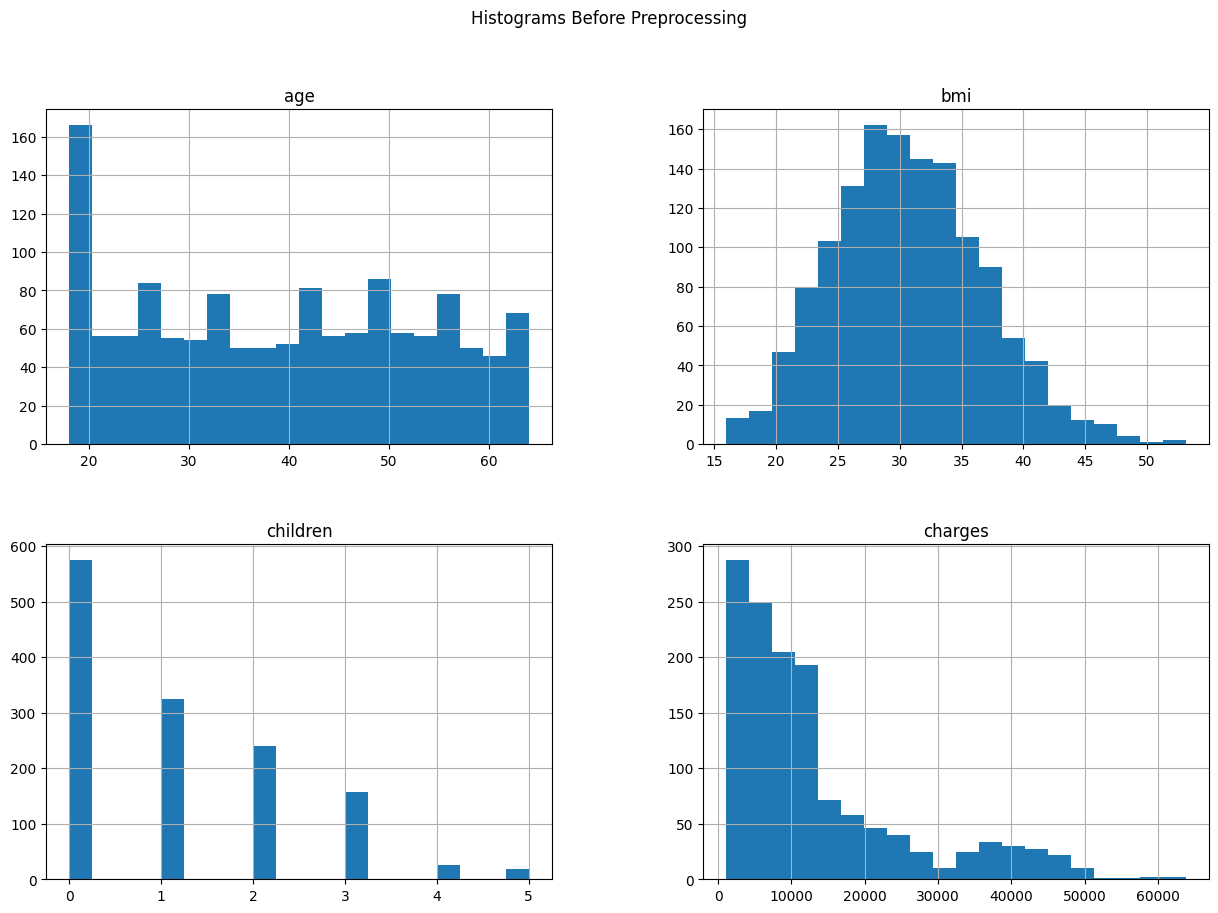

In [51]:
df.hist(figsize=(15,10), bins=20)

plt.suptitle("Histograms Before Preprocessing")

plt.show()

In [52]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [56]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])

In [57]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[["region"]])
print(encoded)

[[0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 ...
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]]


In [58]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


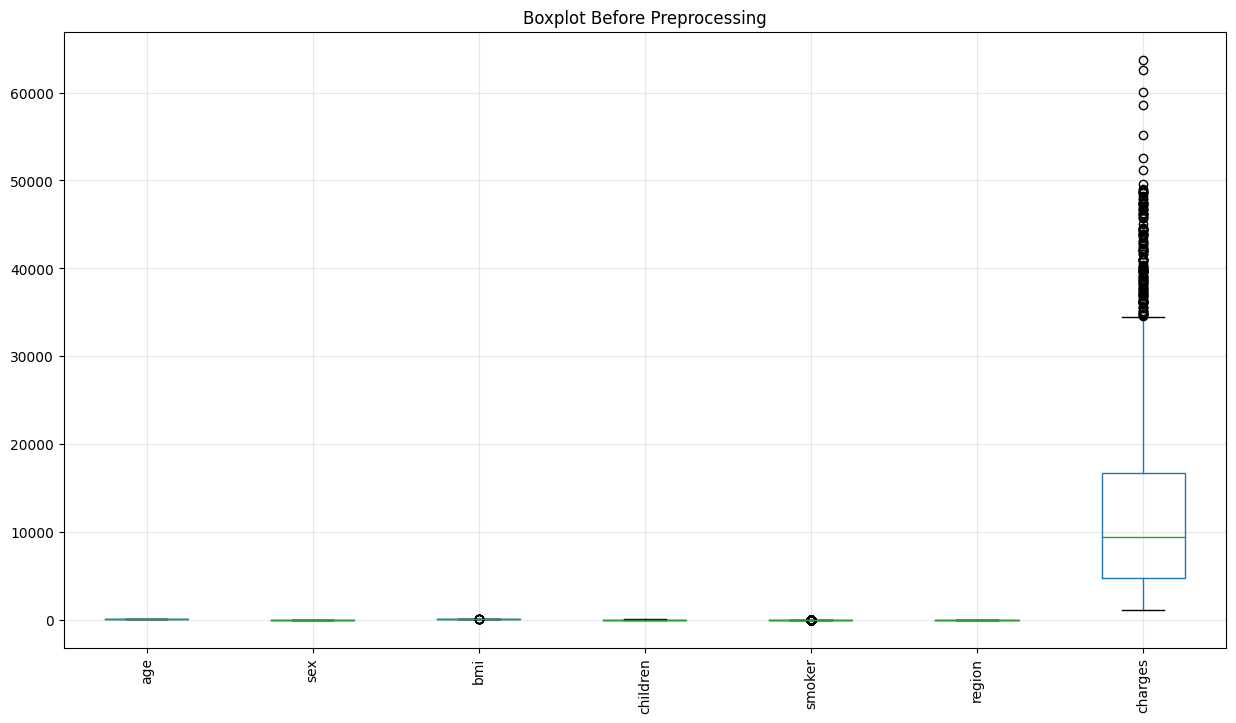

In [59]:
plt.figure(figsize=(15,8))

df.boxplot(rot=90)

plt.title("Boxplot Before Preprocessing")

plt.grid(alpha=0.3)
plt.show()

In [62]:
x = df.drop("charges" , axis =1)
y = df["charges"]

In [65]:
Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlier_count = (((x < lower_bound) | (x > upper_bound)).sum())
print(outlier_count)

age           0
sex           0
bmi           9
children      0
smoker      274
region        0
dtype: int64


In [66]:
X_iqr = x.copy()

for col in X_iqr.columns:

    X_iqr[col] = np.where(
        X_iqr[col] > upper_bound[col],
        upper_bound[col],
        X_iqr[col]
    )

    X_iqr[col] = np.where(
        X_iqr[col] < lower_bound[col],
        lower_bound[col],
        X_iqr[col]
    )

In [72]:
from sklearn.preprocessing import QuantileTransformer , RobustScaler , PowerTransformer

robust = RobustScaler()

X_robust = pd.DataFrame(
    robust.fit_transform(X_iqr),
    columns=X_iqr.columns
)

qt = QuantileTransformer(
    output_distribution='normal',
    n_quantiles=min(100, len(X_robust))
)

X_qt = pd.DataFrame(
    qt.fit_transform(X_robust),
    columns=X_robust.columns
)


pt = PowerTransformer(method='yeo-johnson')

X_power = pd.DataFrame(
    pt.fit_transform(X_qt),
    columns=X_qt.columns
)

In [73]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

X_scaled = pd.DataFrame(
    std.fit_transform(X_power),
    columns=X_power.columns
)

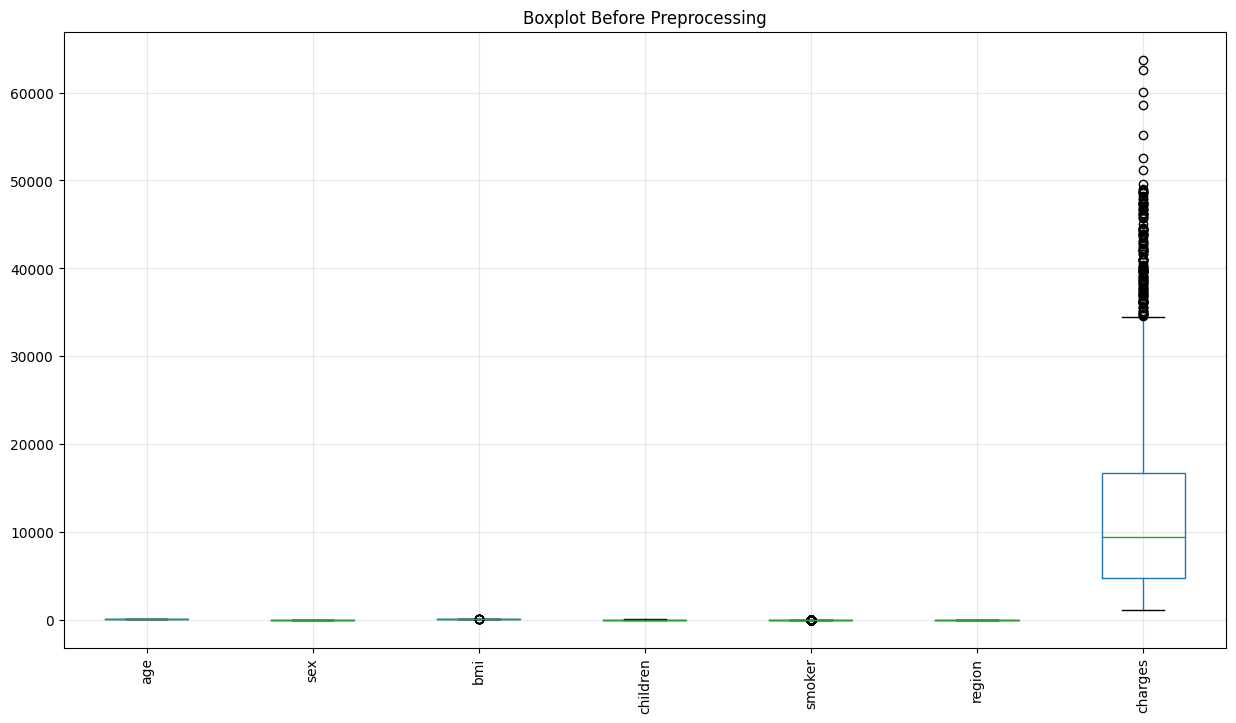

In [74]:
plt.figure(figsize=(15,8))

df.boxplot(rot=90)

plt.title("Boxplot Before Preprocessing")

plt.grid(alpha=0.3)
plt.show()

In [77]:
feature_out = ['bmi' , 'smoker']

for col in feature_out:

    lower_clip = X_scaled[col].quantile(0.15)
    upper_clip = X_scaled[col].quantile(0.85)

    X_scaled[col] = np.clip(
        X_scaled[col],
        lower_clip,
        upper_clip
    )

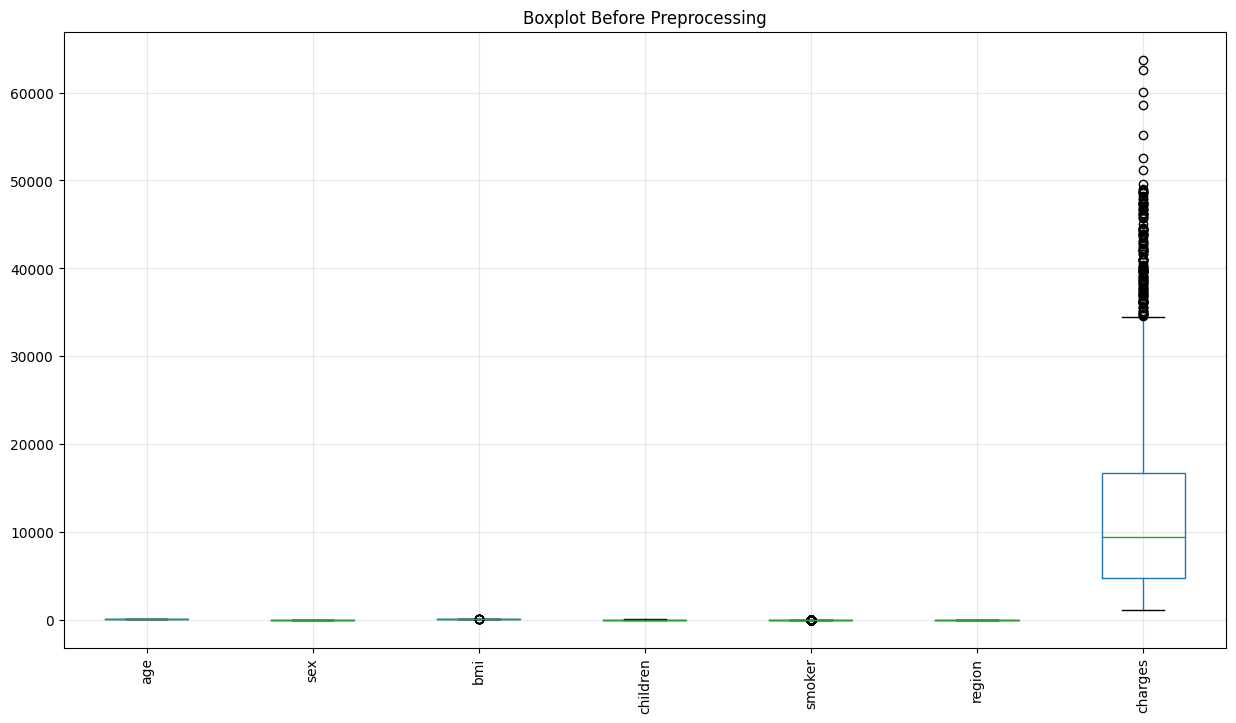

In [78]:
plt.figure(figsize=(15,8))

df.boxplot(rot=90)

plt.title("Boxplot Before Preprocessing")

plt.grid(alpha=0.3)
plt.show()

<Axes: ylabel='bmi'>

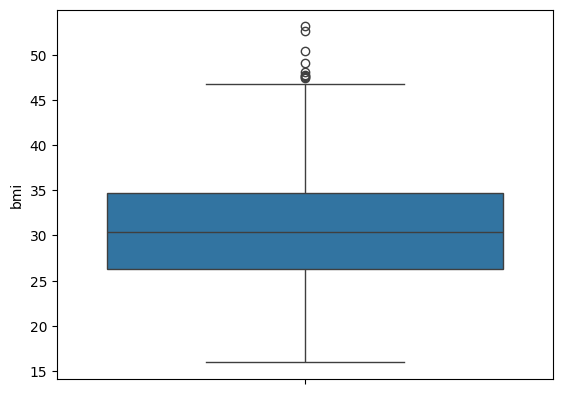

In [79]:
sns.boxplot(df['bmi'])

In [84]:
import numpy as np

df["charges"] = np.log1p(df["charges"])

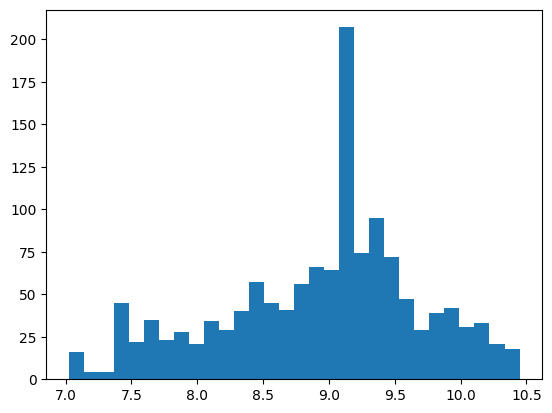

In [85]:
plt.hist(df["charges"], bins=30)
plt.show()

In [87]:
!pip install Lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 439.8 kB/s eta 0:00:00


In [89]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [92]:
from lazypredict.Supervised import LazyRegressor

clf = LazyRegressor(verbose=0 , ignore_warnings=True )
models , predictions = clf.fit(x_train , x_test , y_train , y_test)

print(models)

                               Adjusted R-Squared     R-Squared          RMSE  \
Model                                                                           
GradientBoostingRegressor                0.875250      0.878053  4.351106e+03   
RandomForestRegressor                    0.862292      0.865386  4.571501e+03   
LGBMRegressor                            0.861165      0.864285  4.590160e+03   
HistGradientBoostingRegressor            0.860584      0.863717  4.599759e+03   
XGBRegressor                             0.846723      0.850168  4.822991e+03   
ExtraTreesRegressor                      0.846553      0.850002  4.825667e+03   
BaggingRegressor                         0.846346      0.849799  4.828920e+03   
KNeighborsRegressor                      0.830717      0.834521  5.068565e+03   
AdaBoostRegressor                        0.817199      0.821307  5.267061e+03   
PoissonRegressor                         0.790937      0.795635  5.632711e+03   
Lars                        

In [99]:
from sklearn.ensemble import GradientBoostingRegressor

GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8
)

model.fit(x_train, y_train)

GradientBoostingRegressor(n_estimators=200, random_state=42)

In [100]:
y_pred = model.predict(x_test)

In [101]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8745933824032381
MSE: 19469218.302571207
